In [1]:
from google.colab import files
upload = files.upload()

Saving car data.csv to car data.csv


First 5 Rows
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Shape
(301, 9)

Columns
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Missing Values
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0

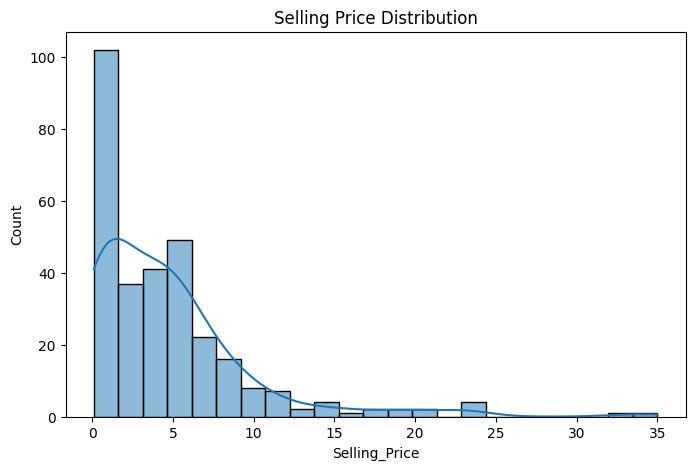

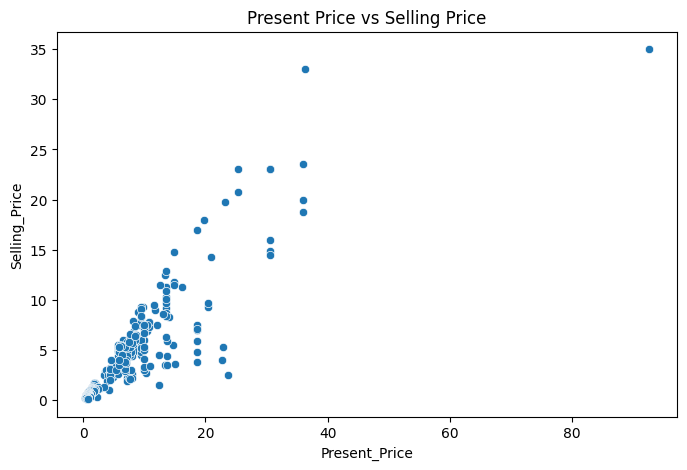

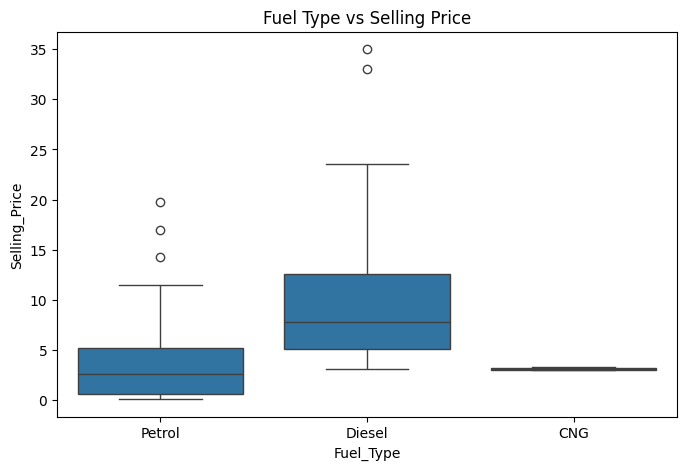


Model Evaluation
MAE = 0.6170163934426232
MSE = 0.8309596783606561
R2 Score = 0.9639271285853968


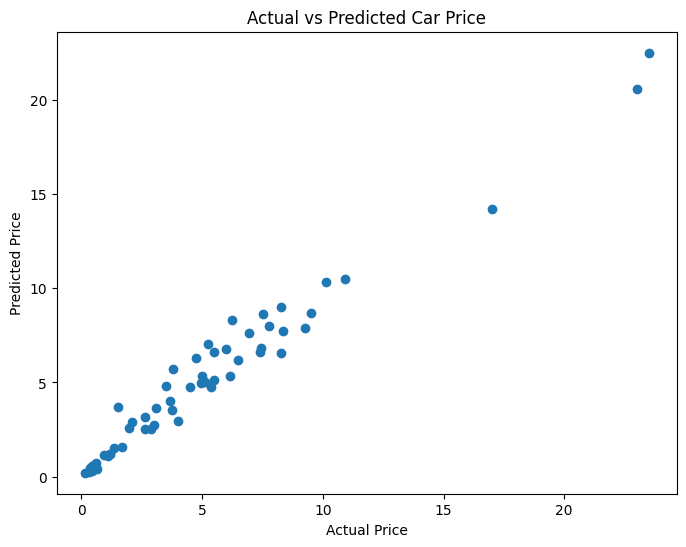


Feature Importance
                     Feature  Importance
0              Present_Price    0.865438
3                    Car_Age    0.058639
1                 Driven_kms    0.031743
104      Transmission_Manual    0.009308
91     Car_Name_land cruiser    0.008078
84         Car_Name_fortuner    0.005850
101         Fuel_Type_Diesel    0.003628
89           Car_Name_innova    0.003410
72             Car_Name_city    0.003322
103  Selling_type_Individual    0.002980


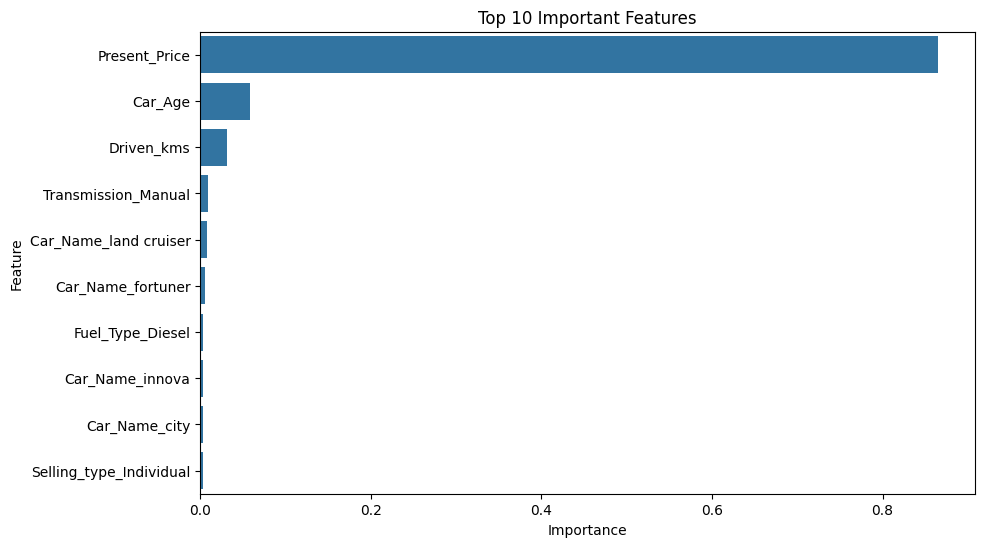


Sample Prediction
Predicted Selling Price = 3.844000000000003


In [2]:
# =====================================
# CAR PRICE PREDICTION WITH ML
# CodeAlpha Task 3
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("car data.csv")

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

# =====================================
# CHECK MISSING VALUES
# =====================================

print("\nMissing Values")
print(df.isnull().sum())

# =====================================
# FEATURE ENGINEERING
# =====================================

current_year = 2025

df["Car_Age"] = current_year - df["Year"]

df.drop("Year", axis=1, inplace=True)

# =====================================
# DATA VISUALIZATION
# =====================================

plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Selling Price Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["Present_Price"],
    y=df["Selling_Price"]
)
plt.title("Present Price vs Selling Price")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Fuel_Type"],
    y=df["Selling_Price"]
)
plt.title("Fuel Type vs Selling Price")
plt.show()

# =====================================
# ENCODE CATEGORICAL DATA
# =====================================

df = pd.get_dummies(
    df,
    drop_first=True
)

# =====================================
# FEATURES & TARGET
# =====================================

X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# TRAIN MODEL
# =====================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================
# PREDICTIONS
# =====================================

y_pred = model.predict(X_test)

# =====================================
# EVALUATION
# =====================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nModel Evaluation")

print("MAE =", mae)
print("MSE =", mse)
print("R2 Score =", r2)

# =====================================
# ACTUAL VS PREDICTED
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

plt.show()

# =====================================
# FEATURE IMPORTANCE
# =====================================

importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# =====================================
# SAMPLE PREDICTION
# =====================================

sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\nSample Prediction")
print("Predicted Selling Price =", prediction[0])